In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

What was the global change to the isoform landscape across a cohort of 96 rare disease samples
-

Isoform expression 
-



In [7]:
meta = pd.read_csv("applied_depletion_gregor_n100/gencode.v49.metadata.HGNC", sep="\t", header=None)
meta.columns = ["Transcript", "Gene name", "HGNC"]
meta['Transcript stable ID'] = meta['Transcript'].str.split('.').str[0]
meta.set_index('Transcript stable ID', inplace=True)
meta = meta[~meta.index.duplicated(keep='first')]
meta = meta['Gene name'].copy()
meta

Transcript stable ID
ENST00000511072       PRDM16
ENST00000607632       PRDM16
ENST00000378391       PRDM16
ENST00000514189       PRDM16
ENST00000270722       PRDM16
                     ...    
ENST00000710671      CCDC120
ENST00000710672      CCDC120
ENST00000400754        MAFIP
ENST00000611446    RNA5-8SN5
ENST00000616292    RNA5-8SN4
Name: Gene name, Length: 412781, dtype: object

In [8]:
data = pd.read_csv("applied_depletion_gregor_n100/rsem/DESeq2_D_vs_WM_paired_results_isoforms_with_means.csv")
data['significant'] = np.where(data['padj'] < 0.05, 'significant', 'not significant')
data['Transcript stable ID'] = data['transcript_id'].str.split('.').str[0]  
data['Gene name'] = data['Transcript stable ID'].map(meta)
data['Gene name'] = data['Gene name'].fillna(data['transcript_id'])
data['-log10(pvalue)'] = -np.log10(data['pvalue'])
data['-log10(pvalue)'] = data['-log10(pvalue)'].replace([np.inf, -np.inf], 300)
data

/Users/jbezney/miniforge3/envs/pegasus/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,transcript_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,mean_WM_norm,mean_D_norm,mean_WM_model,mean_D_model,significant,Transcript stable ID,Gene name,-log10(pvalue)
0,ENST00000684628.1,630.096376,1.061378,0.020370,52.104103,0.000000,0.0,407.365690,852.827061,410.077980,885.330870,significant,ENST00000684628,DPM1,300.000000
1,ENST00000374003.7,230.221361,-2.913648,0.047160,-61.782624,0.000000,0.0,405.406313,55.036409,417.266456,58.460144,significant,ENST00000374003,FGR,300.000000
2,ENST00000374004.5,248.089106,-5.191762,0.126386,-41.078678,0.000000,0.0,480.348104,15.830107,527.299344,15.225122,significant,ENST00000374004,FGR,300.000000
3,ENST00000374005.8,6619.387425,-2.240697,0.018445,-121.481335,0.000000,0.0,10912.262825,2326.512024,10906.612727,2416.802316,significant,ENST00000374005,FGR,300.000000
4,ENST00000399173.5,1363.700609,-3.283663,0.042424,-77.401034,0.000000,0.0,2464.908649,262.492569,2522.719125,269.535298,significant,ENST00000399173,FGR,300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178322,ENST00000845964.1,0.326832,0.201177,2.898460,0.069408,0.944665,NaN,0.194736,0.458927,0.444522,0.512688,not significant,ENST00000845964,ENST00000845964.1,0.024722
178323,ENST00000802874.1,0.215939,0.264921,2.899169,0.091378,0.927192,NaN,0.157022,0.274856,0.317626,0.403243,not significant,ENST00000802874,ENST00000802874.1,0.032830
178324,ENST00000850737.1,0.165273,-0.696581,2.899714,-0.240224,0.810157,NaN,0.302132,0.028413,0.364466,0.233115,not significant,ENST00000850737,ENST00000850737.1,0.091431
178325,ENST00000492564.2,0.345717,-0.049312,2.898428,-0.017013,0.986426,NaN,0.416450,0.274983,0.482700,0.485175,not significant,ENST00000492564,PAXX,0.005935


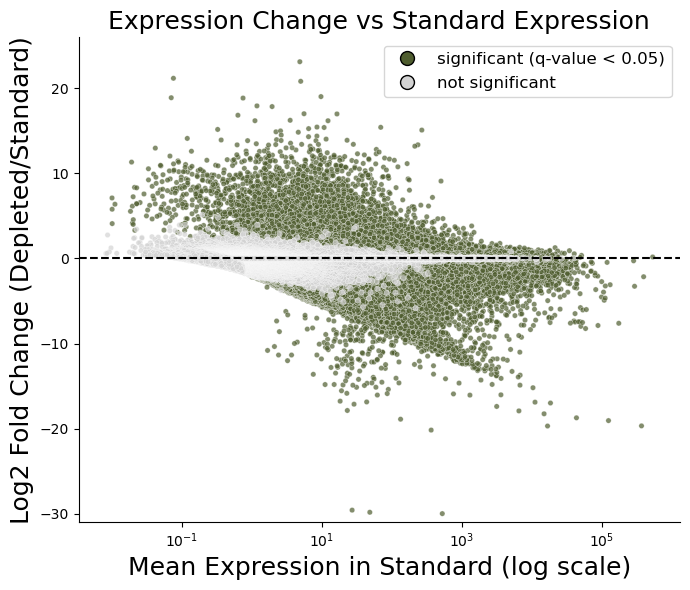

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=data,
    s=15,  # keep point size in the plot
    x='mean_WM_norm',
    y='log2FoldChange',
    hue='significant',
    alpha=0.7,
    palette={'significant': '#4F5D2F', 'not significant': 'lightgrey'},
    ax=ax
)

ax.axhline(0, color='black', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('Mean Expression in Standard (log scale)', fontsize=18)
ax.set_ylabel('Log2 Fold Change (Depleted/Standard)', fontsize=18)
ax.set_title('Expression Change vs Standard Expression', fontsize=18)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='#4F5D2F', markeredgecolor='black', label='significant (q-value < 0.05)'),
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='lightgrey', markeredgecolor='black', label='not significant'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=12)
#remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-31, 26)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/MSE_plot_log2FoldChange_vs_baseMean_isoforms.png', dpi=300)
plt.show()

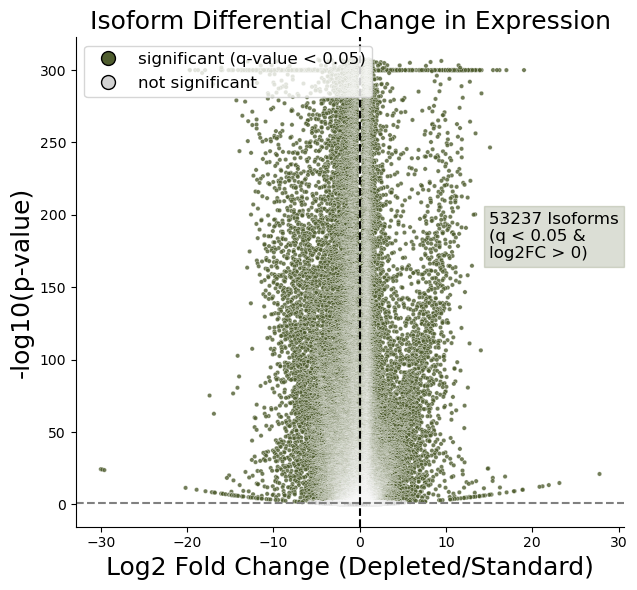

In [10]:
#plot a volcano plot of log2FoldChange vs -log10(pvalue)
fig, ax = plt.subplots(figsize=(6.5, 6))
sns.scatterplot(
    data=data,
    x='log2FoldChange',
    y='-log10(pvalue)',
    hue='significant',
    alpha=0.8,
    s=10,
    palette={'significant': '#4F5D2F', 'not significant': 'lightgrey'},
    ax=ax
)

#add a text box in '#4F5D2F' that counts the number of significant isoforms (q-value < 0.05 with log2FoldChange > 0)
significant_count = data[(data['significant'] == 'significant') & (data['log2FoldChange'] > 0)].shape[0]
ax.text(15, 170, f'{significant_count} Isoforms\n(q < 0.05 & \nlog2FC > 0)',
        fontsize=12, color='black', bbox=dict(facecolor='#4F5D2F', alpha=0.2, edgecolor='#4F5D2F'))

ax.axhline(-np.log10(0.05), color='grey', linestyle='--')
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Log2 Fold Change (Depleted/Standard)', fontsize=18)
ax.set_ylabel('-log10(p-value)', fontsize=18)
ax.set_title('Isoform Differential Change in Expression', fontsize=18)
legend_elems = [
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='#4F5D2F', markeredgecolor='black', label='significant (q-value < 0.05)'),
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='lightgrey', markeredgecolor='black', label='not significant'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=12)
#remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/Volcano_plot_log2FoldChange_vs_-log10_pvalue_isoforms.png', dpi=300)
plt.show()

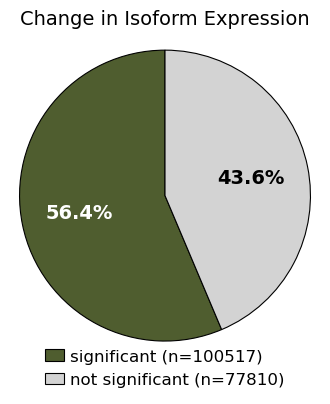

In [11]:
order = ['significant', 'not significant']
colors_map = {'significant': '#4F5D2F', 'not significant': 'lightgrey'}

counts = data['significant'].value_counts()
labels = [lab for lab in order if lab in counts.index]
sizes  = [counts.get(lab, 0) for lab in labels]
colors = [colors_map[lab] for lab in labels]

fig, ax = plt.subplots(figsize=(4, 4))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,  # keeps % a bit inward for readability
    wedgeprops=dict(edgecolor='black', linewidth=0.8)  # thin black outline
)

# Color the % text: white on green, black on grey
for wedge, autot in zip(wedges, autotexts):
    face_rgb = wedge.get_facecolor()[:3]
    if face_rgb == tuple(plt.matplotlib.colors.to_rgb('#4F5D2F')):
        autot.set_color('white')
        autot.set_fontsize(14)
    else:
        autot.set_color('black')
        autot.set_fontsize(14)
    autot.set_fontweight('bold')

# Legend stacked and closer to the pie
ax.legend(
    handles=wedges,
    labels=[f"{lab} (n={cnt})" for lab, cnt in zip(labels, sizes)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),   # closer up under the pie
    ncol=1,
    fontsize=12,
    frameon=False,
    handlelength=1.1,
    handletextpad=0.4,
    borderaxespad=0.0
)

ax.set_title('Change in Isoform Expression', fontsize=14, pad=8)  # tighter title spacing
ax.axis('equal')

# Pull everything closer: reduce bottom margin
plt.subplots_adjust(top=0.90, bottom=0.1)  # tighter than before
plt.savefig('applied_depletion_gregor_n100/paper_figures/isoforms_significant_pie_chart.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [4]:
data = pd.read_csv("applied_depletion_gregor_n100/rsem/isoforms_TPM.tsv", sep="\t")
data = data.fillna(0)
cols_to_average = data.columns[data.columns.str.contains('-WM')]
data['WM_mean'] = data[cols_to_average].mean(axis=1)
data['WM_std'] = data[cols_to_average].std(axis=1)
cols_to_average = data.columns[data.columns.str.contains('-D')]
data['D_mean'] = data[cols_to_average].mean(axis=1)
data['D_std'] = data[cols_to_average].std(axis=1)
data

,transcript_id,gene_id,length,effective_length,1-1-WM,1-2-WM,1-3-WM,1-4-WM,1-5-WM,1-6-WM,...,9-3-D,9-4-D,9-5-D,9-6-D,9-7-D,9-8-D,WM_mean,WM_std,D_mean,D_std
0,ENST00000373020.9,ENSG00000000003.16,3768,3461.19,0.13,0.12,0.16,0.02,0.07,0.08,...,0.34,0.11,0.25,0.23,0.21,0.15,0.090208,0.055288,0.234063,0.110497
1,ENST00000494424.1,ENSG00000000003.16,820,513.28,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.001771,0.007813,0.005417,0.019354
2,ENST00000496771.5,ENSG00000000003.16,1025,718.19,0.00,0.02,0.05,0.00,0.03,0.02,...,0.13,0.04,0.03,0.00,0.00,0.03,0.042917,0.044507,0.088333,0.089309
3,ENST00000612152.4,ENSG00000000003.16,3796,3489.19,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.000937,0.005247,0.000417,0.002478
4,ENST00000373031.5,ENSG00000000005.6,1205,898.19,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.000104,0.001021,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385664,ENST00000409293.6,ENSG00000310576.1,870,563.22,19.39,14.98,15.87,7.90,11.56,11.08,...,18.52,16.79,11.42,18.54,21.26,18.28,15.431146,4.164539,16.429271,4.265320
385665,ENST00000485191.5,ENSG00000310576.1,1675,1368.19,1.49,0.74,1.04,0.50,0.92,0.40,...,0.73,0.48,0.65,0.75,0.53,0.50,0.989271,0.376505,0.519167,0.186179
385666,ENST00000585716.3,ENSG00000310576.1,558,254.22,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.27,0.00,0.40,0.00,0.00,0.016771,0.076509,0.020729,0.098657
385667,ENST00000590269.2,ENSG00000310576.1,751,444.45,0.25,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.16,0.72,0.00,0.00,0.031667,0.074476,0.182292,0.233213


In [5]:
def plot_overlap_stacked_bar(
    data: pd.DataFrame,
    control_col: str,
    depleted_col: str,
    id_col: str = "transcript_id",
    thresholds=(1.0,),
    outfile: str = "overlap_stacked.pdf",
    title: str = "Transcript Overlap",
    greater_equal: bool = False,
    control_label: str = "Control",
    depleted_label: str = "Depleted",
    figsize=(max(6, 1.2*6), 5)
) -> pd.DataFrame:
    """
    Build stacked bars of transcript overlap across thresholds.

    For each threshold k:
      - Control set  = {id | data[control_col]  > k}  (or >= k if greater_equal=True)
      - Depleted set = {id | data[depleted_col] > k}  (or >= k if greater_equal=True)
      - Shared       = intersection(Control, Depleted)
      - Control-only = Control \ Depleted
      - Depleted-only= Depleted \ Control
    Bars show proportions relative to the union size.

    Returns a DataFrame with counts and proportions per k, and saves a PDF to `outfile`.
    """
    # Basic checks
    for c in (id_col, control_col, depleted_col):
        if c not in data.columns:
            raise KeyError(f"Column '{c}' not found in data.")

    # Work on a clean subset (drop NAs, drop duplicate IDs if any)
    sub = data[[id_col, control_col, depleted_col]].dropna().drop_duplicates(id_col)

    # Choose operator
    op = np.greater_equal if greater_equal else np.greater

    # Preserve provided threshold order
    thresholds = list(thresholds)

    rows = []
    for k in thresholds:
        ctrl_mask = op(sub[control_col].to_numpy(), k)
        depl_mask = op(sub[depleted_col].to_numpy(), k)

        ctrl_set = set(sub.loc[ctrl_mask, id_col])
        depl_set = set(sub.loc[depl_mask, id_col])

        shared = ctrl_set & depl_set
        only_ctrl = ctrl_set - depl_set
        only_depl = depl_set - ctrl_set
        union = ctrl_set | depl_set
        denom = len(union)

        if denom == 0:
            prop_shared = prop_ctrl = prop_depl = 0.0
        else:
            prop_shared = len(shared) / denom
            prop_ctrl   = len(only_ctrl) / denom
            prop_depl   = len(only_depl) / denom

        rows.append({
            "k": k,
            "n_union": denom,
            "n_shared": len(shared),
            "n_ctrl_only": len(only_ctrl),
            "n_depl_only": len(only_depl),
            "prop_shared": prop_shared,
            "prop_ctrl_only": prop_ctrl,
            "prop_depl_only": prop_depl,
        })

    stats = pd.DataFrame(rows)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(thresholds))

    # Stacks
    b1 = stats["prop_shared"].to_numpy()
    b2 = stats["prop_ctrl_only"].to_numpy()
    b3 = stats["prop_depl_only"].to_numpy()

    ax.bar(x, b1, color="lightgrey", label="Shared", width=0.9, edgecolor='black', linewidth=0.5)
    ax.bar(x, b2, bottom=b1, color="grey", label=f"{control_label} only", width=0.9, edgecolor='black', linewidth=0.5)
    ax.bar(x, b3, bottom=b1 + b2, color="#A6C48A", label=f"{depleted_label} only", width=0.9, edgecolor='black', linewidth=0.5)

    # X axis
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in thresholds])
    ax.set_xlabel("TPM Threshold", fontsize=16)
    ax.set_ylabel("Proportion of Isoforms", fontsize=16)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=25, fontsize=16)

    # Legend outside (right)
    # move right margin a bit to make room, then anchor legend just outside
    fig.subplots_adjust(right=0.78)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=12)

    # Annotate union size above each bar
    for i, n in enumerate(stats["n_union"]):
        ax.text(i, 1.02, f"{n}", ha="center", va="bottom", fontsize=9)

    # Percent labels centered in each segment (black)
    for i in range(len(thresholds)):
        if stats.loc[i, "n_union"] == 0:
            continue
        # shared
        y_shared = b1[i] / 2.0
        ax.text(i, y_shared, f"{int(round(b1[i]*100))}%", ha="center", va="center", fontsize=11, color="black")
        # control-only
        y_ctrl = b1[i] + b2[i] / 2.0
        ax.text(i, y_ctrl, f"{int(round(b2[i]*100))}%", ha="center", va="center", fontsize=11, color="white")
        # depleted-only
        y_depl = b1[i] + b2[i] + b3[i] / 2.0
        ax.text(i, y_depl, f"{int(round(b3[i]*100))}%", ha="center", va="center", fontsize=11, color="black")

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight", dpi=300)
    plt.show()

    return stats

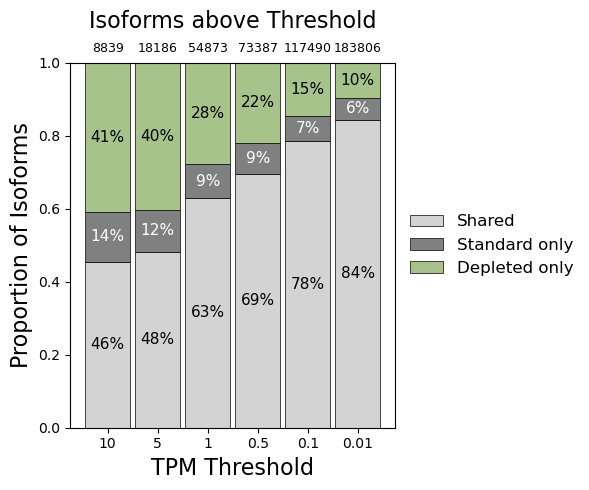

In [6]:
k = [10, 5, 1, 0.5, 0.1, 0.01]
stats = plot_overlap_stacked_bar(
    data=data,
    control_col="WM_mean",
    depleted_col="D_mean",
    id_col="transcript_id",
    thresholds=k,
    outfile="applied_depletion_gregor_n100/paper_figures/TPM_transcript_overlap_stacked.png",
    title='Isoforms above Threshold',
    greater_equal=False,            
    control_label="Standard",
    depleted_label="Depleted",
    figsize=(6,5),
)